# Progree Task 4 | Frame metrics and controlled evaluation
Execute the full benchmark and generate the canonical artifacts used by the README and whitepaper. All results below come from this run.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0,str(ROOT))
import pandas as pd
from IPython.display import display, Image
from src.video_processor import processVideo

from benchmark import evaluateSynthetic
from generate_demo import generateDemo


## Process every frame
Generation and processing are deterministic in content; measured runtime varies with machine load. The per-frame denominator excludes export and source decoding.

In [2]:
generateDemo()
run=processVideo(ROOT/"data/sample_shapes.mp4",ROOT/"outputs",roi=(.2,.1,.8,.9),line=.5)
df=pd.read_csv(ROOT/"outputs/frame_metrics.csv")
assert len(df)==240
display(pd.DataFrame([run["summary"]]).T)

,0
total_frames,240
successful_frames,240
average_processing_time_ms,19.187375
median_processing_time_ms,19.0028
minimum_processing_time_ms,14.6104
maximum_processing_time_ms,24.3546
p95_processing_time_ms,22.74939
average_fps,52.742389
minimum_fps,41.060005
maximum_fps,68.444396


## Latency, FPS, counts and tracks
The mean of per-frame FPS differs from 1000 divided by mean latency. Aggregate processing FPS is the latter and is the dashboard headline. P95 reveals slower frames.

,frame_number,timestamp_seconds,objects_detected,active_tracks,processing_time_ms,fps,contour_count_raw,contour_count_filtered,inference_time_ms,class_counts,roi_objects,roi_class_counts,entered,exited,circle_count,rectangle_count,triangle_count,other_count
0,1,0.000000,3,3,22.8385,43.785713,3,3,NaN,"{""Triangle"": 1, ""Rectangle"": 1, ""Circle"": 1}",0,{},0,0,1,1,1,0
1,2,0.033333,3,3,20.2622,49.352982,3,3,NaN,"{""Triangle"": 1, ""Rectangle"": 1, ""Circle"": 1}",0,{},0,0,1,1,1,0
2,3,0.066667,3,3,20.2454,49.393936,3,3,NaN,"{""Triangle"": 1, ""Rectangle"": 1, ""Circle"": 1}",0,{},0,0,1,1,1,0
3,4,0.100000,3,3,21.1835,47.206552,3,3,NaN,"{""Triangle"": 1, ""Rectangle"": 1, ""Circle"": 1}",0,{},0,0,1,1,1,0
4,5,0.133333,3,3,17.3593,57.606009,3,3,NaN,"{""Triangle"": 1, ""Rectangle"": 1, ""Circle"": 1}",0,{},0,0,1,1,1,0


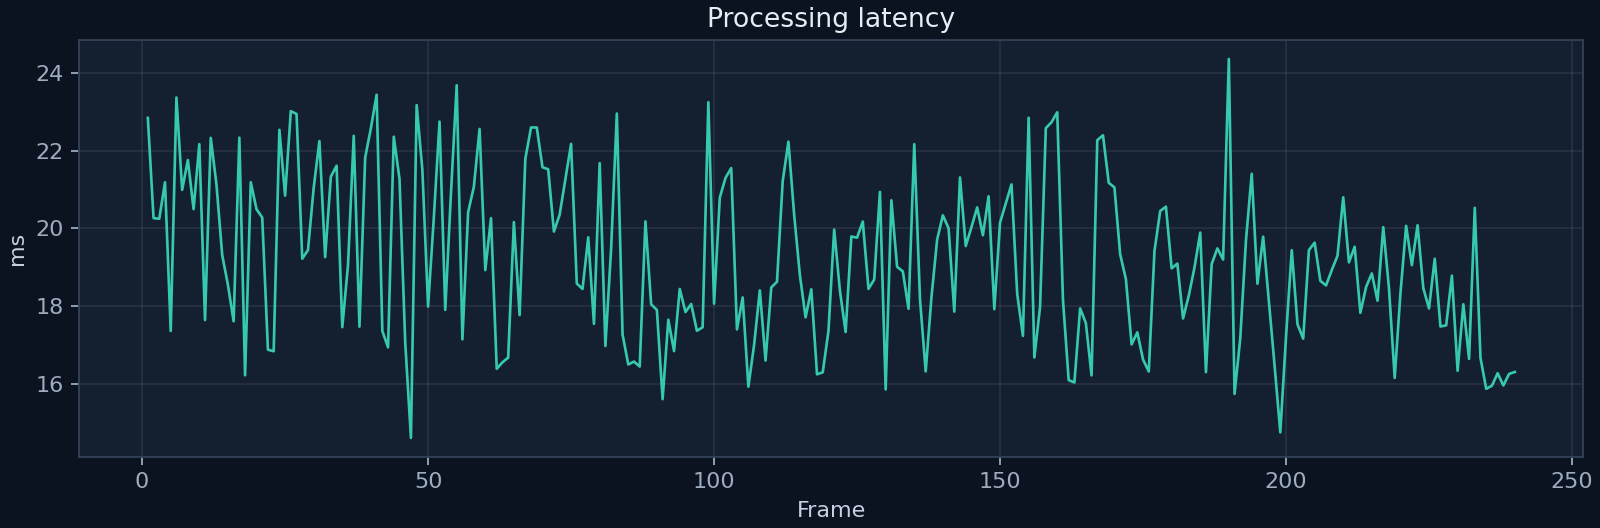

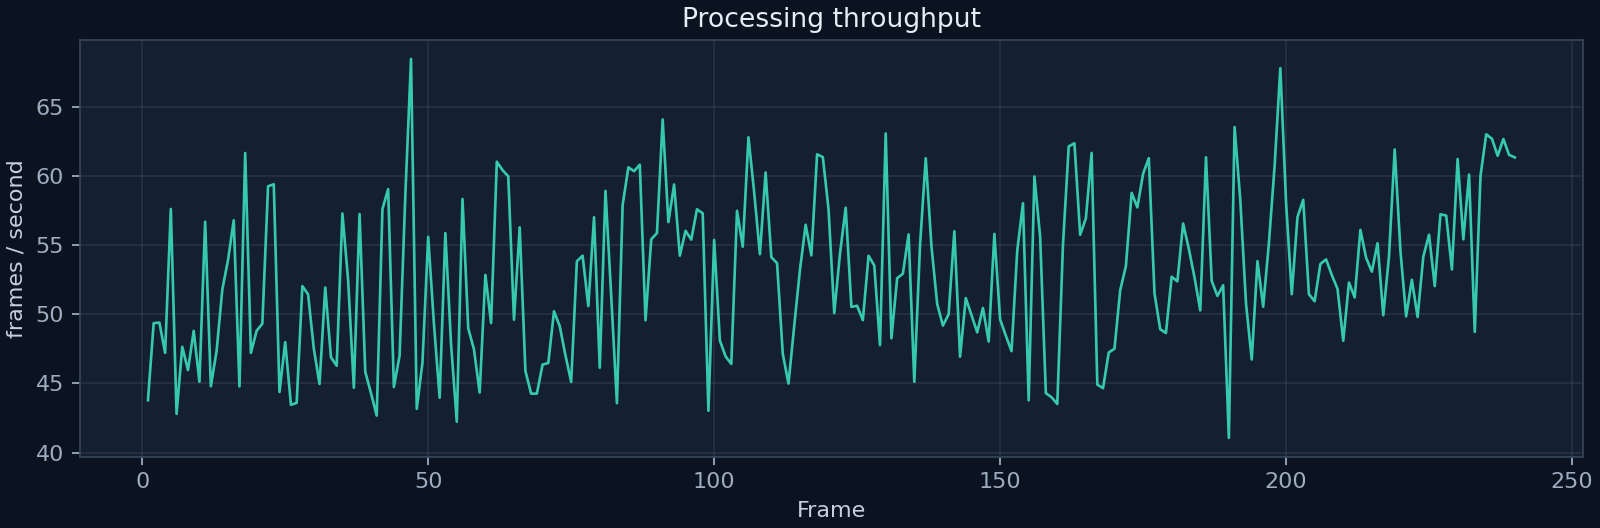

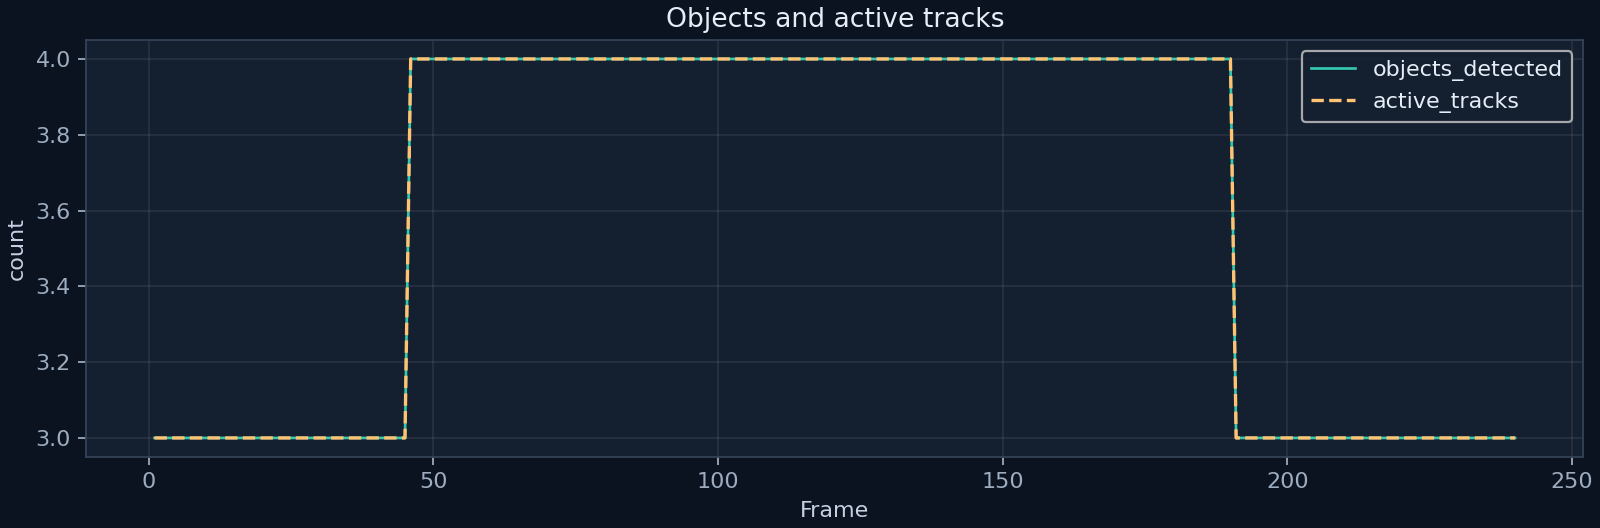

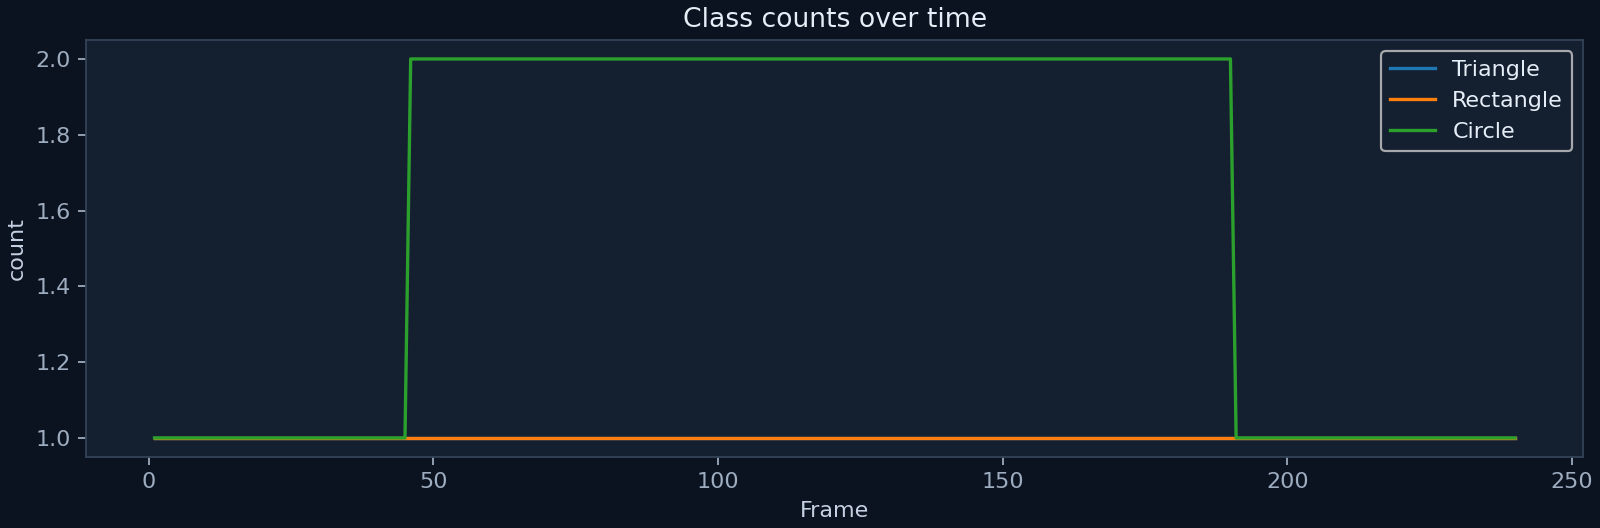

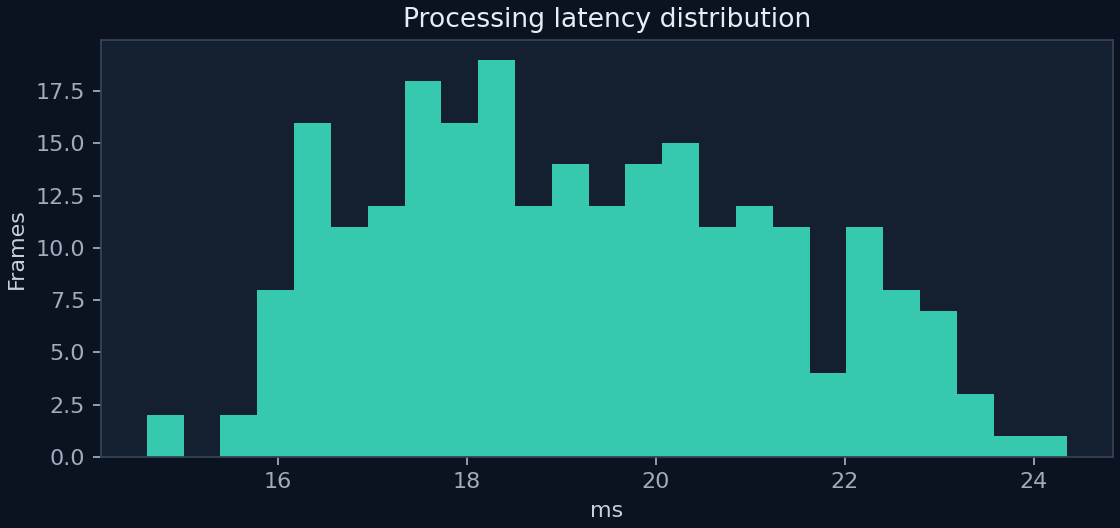

In [3]:
display(df.head())
for name in ["processing_time_by_frame","fps_by_frame","object_count_by_frame","shape_counts_by_frame","latency_distribution"]:
    display(Image(filename=str(ROOT/"outputs/charts"/(name+".png"))))

## Ground truth correspondence
Greedy one-to-one nearest-centroid matching has a fixed 20 pixel tolerance. It is valid here because objects occupy separate lanes. Evaluate object-frame instances, geometric labels and count error; do not call these mAP or general-world accuracy.

In [4]:
quality=evaluateSynthetic()
display(pd.DataFrame([quality]).T)

,0
matching_rule,Greedy one-to-one nearest centroid <= 20 pixel...
matched,865
false_positives,0
missed,0
centroid_precision,1.0
centroid_recall,1.0
shape_accuracy_on_matches,1.0
mean_center_error_px,0.399997
count_mae,0.0
count_exact_frame_fraction,1.0


## Interpretation and limits
The generated sequence contains appearance/disappearance but no occlusion or overlapping shapes. Zero errors here do not establish generalization. Compare YOLO runtime only on identical inputs and disclose that pretrained COCO classes differ from geometric labels. See run.json for the machine, configuration and timing scope.